<a href="https://colab.research.google.com/github/Ash92367/Suduko/blob/main/cvselection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U scikit-learn pymupdf pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 107.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [ ]:
!pip install pdfplumber


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 40.7 MB/s eta 0:00:00


In [ ]:
import zipfile
import os
import fitz  # PyMuPDF (not used now, but you kept it)
import pdfplumber
import pandas as pd
import numpy as np
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [ ]:
with zipfile.ZipFile("/content/sample_data/resume.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/resume")

extract_folder = "/content/resume"

In [ ]:
def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""
    return text

In [ ]:
def extract_experience(text):
    match = re.search(r"(\d+)\s*years?\s*of\s*experience", text, re.IGNORECASE)  # Regex to find years of experience
    return int(match.group(1)) if match else 0  # Return number of years if found, otherwise return 0

def extract_education(text):
    # Convert the text to lowercase for case-insensitive matching
    text = text.lower()
    if "phd" in text:
        return "PhD"
    elif "masters" in text:
        return "Masters"
    elif "bachelors" in text:
        return "Bachelors"
    return "None"

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Re-defining the determine_label function to enforce the new rules
def determine_label(years_of_experience, skills_count, education_level):
    # Create a dictionary for ranking education levels (encoded categories)
    education_rank = {
        0: "Bachelors",
        1: "Masters",
        2: "PhD",
        3: "None"
    }

    # Explicit education check based on encoded values
    if education_level >= 1:  # Bachelors, Masters, or PhD (encoded as 1 or higher)
        if years_of_experience >= 2:  # If Experience >= 2 years
            return "Suitable"
        elif skills_count >= 4:  # If Experience < 2 years, but Skills >= 4
            return "Suitable"
        else:
            return "Not Suitable"
    else:
        return "Not Suitable"  # If education is None or lower than Bachelors


def extract_skills(text):
    skills = ["Python", "Machine Learning", "Data Analysis", "SQL", "TensorFlow"]  # Define relevant skills
    text = text.lower()  # Convert the text to lowercase for case-insensitive matching
    extracted_skills = [skill for skill in skills if skill.lower() in text]  # Find matching skills in text
    return len(extracted_skills)  # Return the count of extracted skills


def calculate_matching_score(text):
    text = text.lower()  # Convert the text to lowercase for case-insensitive matching
    return len(re.findall(r"python|machine learning|data science|sql", text)) / 5  # Calculate matching score based on keywords



In [ ]:
resume_data = []
pdf_files = []

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.lower().endswith('.pdf'):
            pdf_files.append(os.path.join(root, file))

print("PDF files found:", pdf_files)

for pdf_file in pdf_files:
    text = extract_text_from_pdf(pdf_file)
    years_of_experience = extract_experience(text)
    education_level = extract_education(text)
    skills_count = extract_skills(text)
    matching_score = calculate_matching_score(text)

    # Encode education level before passing to determine_label
    encoded_edu = label_encoder.transform([education_level])[0]

    label = determine_label(years_of_experience, skills_count, encoded_edu)

    resume_data.append([years_of_experience, education_level, skills_count, matching_score, label])




PDF files found: ['/content/resume/resume/8.pdf', '/content/resume/resume/3.pdf', '/content/resume/resume/6.pdf', '/content/resume/resume/9.pdf', '/content/resume/resume/1.pdf', '/content/resume/resume/20.pdf', '/content/resume/resume/5.pdf', '/content/resume/resume/11.pdf', '/content/resume/resume/16.pdf', '/content/resume/resume/7.pdf', '/content/resume/resume/14.pdf', '/content/resume/resume/13.pdf', '/content/resume/resume/12.pdf', '/content/resume/resume/10.pdf', '/content/resume/resume/2.pdf', '/content/resume/resume/4.pdf', '/content/resume/resume/19.pdf', '/content/resume/resume/15.pdf', '/content/resume/resume/18.pdf', '/content/resume/resume/17.pdf']


[2 1 0 3]


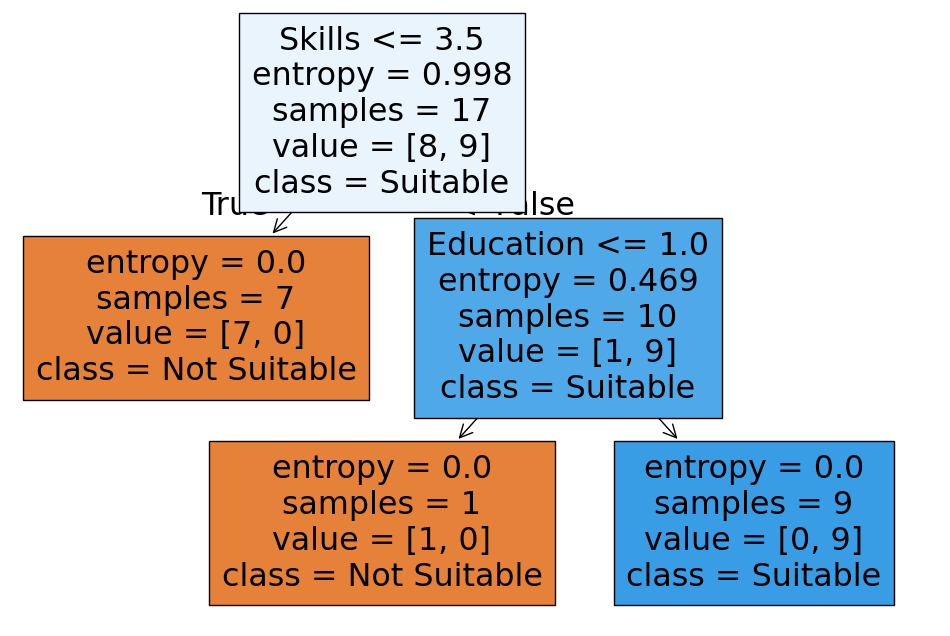

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00         3
    Suitable       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Test Input Features:
    Experience  Education  Skills  Matching_Score
0           1          3       5             0.6
Prediction: Suitable


In [ ]:
columns = ["Experience", "Education", "Skills", "Matching_Score", "Label"]
df = pd.DataFrame(resume_data, columns=columns)

# Fix any stray whitespace in labels (e.g., extra spaces)
df['Label'] = df['Label'].str.strip()

label_encoder = LabelEncoder()
df['Education'] = label_encoder.fit_transform(df['Education'])  # Ensure education is encoded numerically

# Now, check the unique values after encoding
print(df['Education'].unique())  # Encode education level into numeric values

# Step 8: Standardize the Experience feature (to make it comparable with Education)
scaler = StandardScaler()
df['Experience'] = scaler.fit_transform(df[['Experience']])  # Standardize Experience to have a mean of 0 and std deviation of 1

# Step 9: Balance the dataset (upsample the minority class, "Suitable")
df_minority = df[df['Label'] == 'Suitable']
df_majority = df[df['Label'] == 'Not Suitable']

# Upsample the minority class (Suitable)
df_minority_upsampled = resample(df_minority,
                                 replace=True,  # Sample with replacement
                                 n_samples=len(df_majority),  # Match the majority class size
                                 random_state=42)

# Combine the upsampled minority class with the majority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Step 10: Prepare training and testing data (features and labels)
X = df_upsampled.drop('Label', axis=1)  # Features (all columns except Label)
y = df_upsampled['Label']  # Target label (Suitable or Not Suitable)

# Step 11: Split data into training and testing datasets, using stratified sampling to ensure balanced data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 12: Train the Decision Tree classifier with improved hyperparameters
# Step 12: Train the Decision Tree classifier with improved hyperparameters
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_split=4, random_state=42)
clf.fit(X_train, y_train)

# Step 13: Visualize the decision tree to ensure proper decision logic
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=clf.classes_)
plt.show()


# Step 14: Make predictions on the test data
y_pred = clf.predict(X_test)  # Get the prediction
print("Accuracy:", accuracy_score(y_test, y_pred))  # Print the accuracy of the model
print("Classification Report:\n", classification_report(y_test, y_pred))  # Print detailed classification report

# Step 15: Predict on a new test case
new_resume_text = """
I have done PhD. I have 1 year of experience in Python development, SQL databases, and Machine Learning.
Worked extensively on Data Analysis and built models using TensorFlow.
"""

# Step 16: Extract features from the test resume
years = extract_experience(new_resume_text)
edu = extract_education(new_resume_text)
skills = extract_skills(new_resume_text)
score = calculate_matching_score(new_resume_text)
encoded_edu = label_encoder.transform([edu])[0]  # Ensure the encoding is consistent with training

# Prepare input data for prediction
input_df = pd.DataFrame([[years, encoded_edu, skills, score]], columns=["Experience", "Education", "Skills", "Matching_Score"])
print("Test Input Features:\n", input_df)  # Verify the input features before prediction

# Step 17: Make the prediction for the new resume
prediction = clf.predict(input_df)  # Get the prediction
print("Prediction:", prediction[0])  # Print the prediction



In [ ]:
new_resume_text = """
I have done phd. I have 5 year of experience in Python development, SQL databases, and Machine Learning.
Worked extensively on Data Analysis and built models using TensorFlow.
"""

years = extract_experience(new_resume_text)
edu = extract_education(new_resume_text)
skills = extract_skills(new_resume_text)
score = calculate_matching_score(new_resume_text)
encoded_edu = label_encoder.transform([edu])[0]

input_df = pd.DataFrame([[years, encoded_edu, skills, score]],
                        columns=["Experience", "Education", "Skills", "Matching_Score"])

result = clf.predict(input_df)
print("Prediction:", result[0])

Prediction: Suitable


Second Resume Prediction (Should be Suitable): Not Suitable
